# GenoDrawing: SNP-to-image prediction (minimal reproduction)

Reproduction of the inference demonstration from **Dujak et al., "GenoDrawing: An Autoencoder
Framework for Image Prediction from SNP Markers", *Plant Phenomics* 5:0113 (2023)**
(doi:[10.34133/plantphenomics.0113](https://doi.org/10.34133/plantphenomics.0113)),
using the authors' pinned repository
[Fedjurrui/GenoDrawing @ `f4704eabb7f0`](https://github.com/Fedjurrui/GenoDrawing/tree/f4704eabb7f084d990a6db27b108f17e621bcd8c)
and the released autoencoder weights
[aranzana-lab/genodrawing](https://huggingface.co/aranzana-lab/genodrawing) (MIT).

**Scope (partial demonstration — pretrained inference only):** rebuild the authors'
`GenoDrawing.ipynb` example: for the three provided apple genotypes (**2990, 12_j001, 2872**)
compute the encoder mean embedding of their example images, feed the genotype's 150 SNPs
into the trained embedding predictors, decode the predicted embeddings with the frozen
decoder, and compose the authors' 4-column comparison figure (example images / mean decoded
images / targeted-tSNP version / random-rSNP version). Training is out of scope; the original
apple image dataset is only available from the authors on request.

**実行内容（日本語）:** 著者らの学習済み GenoDrawing モデル（オートエンコーダ＋埋め込み予測器）を
読み込み，リポジトリ提供の 3 genotype 例（2990, 12_j001, 2872）について SNP 150 個から画像を生成し，
論文 Figure のような 4 列比較図（例画像／平均デコード画像／targeted tSNP／random rSNP）を再構成します．
学習は対象外です（元画像データセットは入手制限のため非公開）．

**Execution status:** NOT YET EXECUTED in this copy — run all cells top to bottom.
This notebook is a faithful reassembly of the authors' own notebook cells with pinned
download URLs; no re-implementation of the model.

## Runtime selection

This example is lightweight (small conv autoencoder, 3 genotypes × ~10 small images), so the
**CPU runtime is fully sufficient and recommended** (`ランタイム → ランタイムのタイプを変更 → CPU`).
The authors note GPU improves inference speed but is "not strictly required"; the notebook
autodetects the device exactly like the authors' cell 1, so a **T4 GPU runtime also works
unchanged**. Expected total download ≈ 350 MB (the two released autoencoder weights are
~170 MB each); expected wall time on CPU ≈ 5–15 minutes.

**実行環境:** 例は軽量なので CPU で十分です（推奨）．著者のコードと同じ自動判定により T4 GPU でも
そのまま動作します．ダウンロード約 350 MB，CPU で数分〜十数分を見込んでください．

**Environment check.** Print Python/torch versions and select the device exactly as the authors' `GenoDrawing.ipynb` cell 1 does: CUDA if available, otherwise CPU. All later cells use this single `device` variable.

In [ ]:
import os, sys, torch
from torchvision.transforms.functional import to_pil_image
print("python", sys.version.split()[0])
print("torch", torch.__version__)
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", device)

python 3.13.16
torch 2.11.0+cpu
device: cpu


**Dependency setup.** The authors' `requirements.txt` pins `pandas-plink==2.2.9` (with torch 1.13/pandas 1.5, which have no wheels for Colab's current Python). We keep the pinned **pandas-plink 2.2.9** — verified to install and read the authors' PLINK files on current Colab — and use the preinstalled torch 2.x: the author checkpoints are plain state-dicts whose loading is version-tolerant (verified key/shape match against `GenoDrawingLib/models.py`).

**依存関係:** 著者指定の pandas-plink 2.2.9 をそのままインストールします（torch は Colab 標準の 2.x を使用．チェックポイントは state-dict であり読み込み互換を検証済み）．

In [ ]:
%pip install -q pandas-plink==2.2.9
import pandas_plink, pandas
print("pandas_plink", pandas.__version__ and "2.2.9", "| pandas", pandas.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 2.4 MB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


  Preparing metadata (pyproject.toml) ... done


pandas_plink 2.2.9 | pandas 2.2.3


**Pinned input/weight acquisition.** Everything below is downloaded *inside this notebook* from public pinned URLs:

- Data & embedding-predictor weights: GitHub `Fedjurrui/GenoDrawing` @ `f4704eabb7f0` (raw URLs):
  `Snp_data/SNPs_dataset.{bed,bim,fam}` (3 genotypes × 303,239 SNPs), `Snp_data/Final_list_snps.csv`
  (150 targeted tSNPs), `Snp_data/list_random.csv` (150 random rSNPs), 29 example apple-half JPGs
  (genotypes 2990 / 12_j001 / 2872, ~159 KB), and the two 259,935-byte embedding predictors.
- Autoencoder weights (encoder + decoder, ~170 MB each): Hugging Face
  `aranzana-lab/genodrawing` resolve URLs copied from the repository README (MIT).

The Example_images file list is obtained from the pinned commit's git tree API (no hardcoded manifest).
**約 350 MB を /content にダウンロードします**（HF の AE 重み 2 ファイルが大半）．

In [ ]:
import json, os
from urllib.parse import quote
from urllib.request import Request, urlopen

REPO = "Fedjurrui/GenoDrawing"
COMMIT = "f4704eabb7f084d990a6db27b108f17e621bcd8c"  # verified pinned revision (2023-11-15)
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
BASE = "/content/genod"
os.makedirs(BASE, exist_ok=True)

def fetch(url, dest):
    req = Request(url, headers={"User-Agent": "genodrawing-colab-repro"})
    with urlopen(req, timeout=300) as r, open(dest, "wb") as f:
        f.write(r.read())
    return os.path.getsize(dest)

for p in ["Snp_data/SNPs_dataset.bed", "Snp_data/SNPs_dataset.bim", "Snp_data/SNPs_dataset.fam",
          "Snp_data/Final_list_snps.csv", "Snp_data/list_random.csv",
          "Embedding_predictors/Embedding_targeted/model_data_9_2_2023_15h/embedding_predictor_9_2_2023_15h.h5",
          "Embedding_predictors/Embedding_random/model_data_150_snps_iter_1/150_snps.h5"]:
    d = os.path.join(BASE, p); os.makedirs(os.path.dirname(d), exist_ok=True)
    print(p, fetch(f"{RAW}/{p}", d), "bytes")

req = Request(f"https://api.github.com/repos/{REPO}/git/trees/{COMMIT}?recursive=1",
              headers={"User-Agent": "genodrawing-colab-repro"})
tree = json.load(urlopen(req, timeout=60))
assert not tree.get("truncated", False), "truncated tree listing"
img_paths = sorted(t["path"] for t in tree["tree"]
                   if t["path"].startswith("Example_images/") and t["type"] == "blob")
assert len(img_paths) == 29, f"expected 29 example images, got {len(img_paths)}"
for p in img_paths:
    d = os.path.join(BASE, p); os.makedirs(os.path.dirname(d), exist_ok=True)
    fetch(f"{RAW}/{quote(p)}", d)
print("example images:", len(img_paths), "genotypes:",
      sorted({os.path.basename(os.path.dirname(p)) for p in img_paths}))

Snp_data/SNPs_dataset.bed 303242 bytes


Snp_data/SNPs_dataset.bim 9758709 bytes
Snp_data/SNPs_dataset.fam 63 bytes


Snp_data/Final_list_snps.csv 1953 bytes
Snp_data/list_random.csv 1950 bytes


Embedding_predictors/Embedding_targeted/model_data_9_2_2023_15h/embedding_predictor_9_2_2023_15h.h5 259935 bytes
Embedding_predictors/Embedding_random/model_data_150_snps_iter_1/150_snps.h5 259935 bytes


example images: 29 genotypes: ['12_j001', '2872', '2990']


**Autoencoder weights from Hugging Face.** Download the released encoder/decoder state-dicts (torch pickles, despite the `.h5` names — the authors load them with `torch.load`). Place them at the exact paths the authors' notebook expects.

In [ ]:
W = {
 "AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/encoder_7_2_2023_15h.h5":
   "https://huggingface.co/aranzana-lab/genodrawing/resolve/main/encoder_7_2_2023_15h.h5?download=true",
 "AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/decoder_7_2_2023_15h.h5":
   "https://huggingface.co/aranzana-lab/genodrawing/resolve/main/decoder_7_2_2023_15h.h5?download=true",
}
for p, u in W.items():
    d = os.path.join(BASE, p); os.makedirs(os.path.dirname(d), exist_ok=True)
    print(p, fetch(u, d), "bytes")

AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/encoder_7_2_2023_15h.h5 169914773 bytes


AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/decoder_7_2_2023_15h.h5 169943268 bytes


**Byte-level verification.** Reject LFS pointers / error HTML: every `.h5` must start with the torch pickle `PK` magic; the PLINK `.bed` must have its 3-byte magic header and the expected 303,242-byte size; every example image must be a valid 300×300 JPEG. **ダウンロード検証:** ファイルサイズ・マジック・画像寸法を確認します．

In [ ]:
from PIL import Image
import pandas as pd

enc_p = f"{BASE}/AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/encoder_7_2_2023_15h.h5"
dec_p = f"{BASE}/AE_model/64_encoders_35_epochs/model_data_7_2_2023_15h/decoder_7_2_2023_15h.h5"
tp_p  = f"{BASE}/Embedding_predictors/Embedding_targeted/model_data_9_2_2023_15h/embedding_predictor_9_2_2023_15h.h5"
rp_p  = f"{BASE}/Embedding_predictors/Embedding_random/model_data_150_snps_iter_1/150_snps.h5"
for p in [enc_p, dec_p, tp_p, rp_p]:
    assert open(p, "rb").read(2) == b"PK", f"not a torch pickle: {p}"

bed = open(f"{BASE}/Snp_data/SNPs_dataset.bed", "rb").read(3)
assert bed[:2] == b"\x6c\x1b", f"bad bed magic: {bed!r}"
assert os.path.getsize(f"{BASE}/Snp_data/SNPs_dataset.bed") == 303242

bad = []
for p in img_paths:
    im = Image.open(os.path.join(BASE, p)); im.load()
    if im.size != (300, 300): bad.append((p, im.size))
assert not bad, bad
print("verified: 4 torch-pickle weights, bed magic + size, 29 valid 300x300 jpgs")

verified: 4 torch-pickle weights, bed magic + size, 29 valid 300x300 jpgs


### Input preview

**Example apple-half images.** The three genotypes the authors use in `GenoDrawing.ipynb`, showing the first 4 of ~10 stored 300×300 RGB half-apple images each (all 10 per genotype are used for the mean embedding). Directly observed inputs from the pinned commit — no interpretation yet.

**入力プレビュー:** 3 genotype 分の例画像（各 genotype 約 10 枚中 4 枚）を表示します．

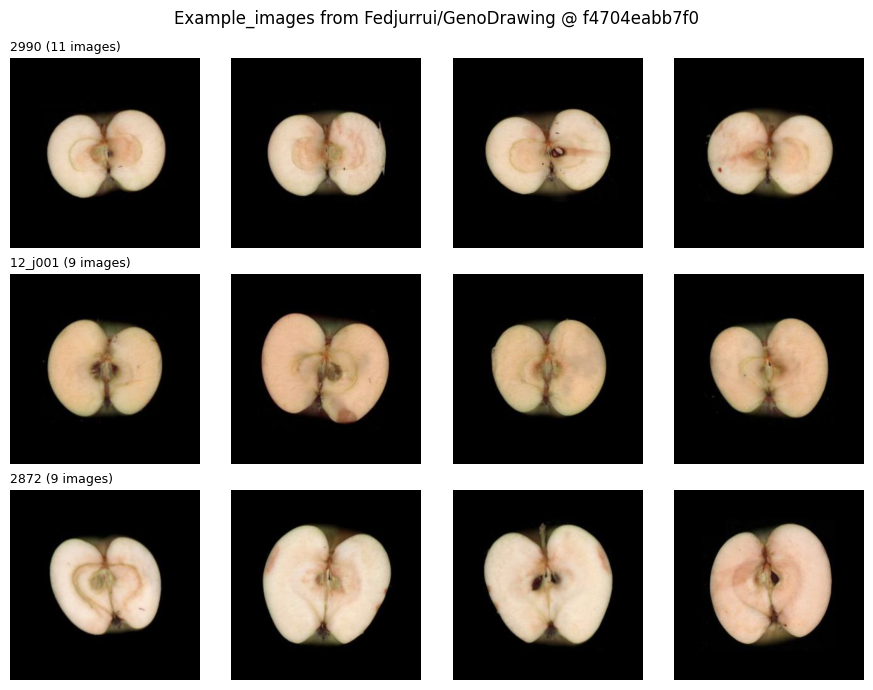

In [ ]:
import matplotlib.pyplot as plt

genos = ["2990", "12_j001", "2872"]
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for r, g in enumerate(genos):
    gdir = os.path.join(BASE, "Example_images", g)
    files = sorted(os.listdir(gdir))[:4]
    for c, fn in enumerate(files):
        axes[r, c].imshow(Image.open(os.path.join(gdir, fn)))
        axes[r, c].set_axis_off()
        if c == 0: axes[r, c].set_ylabel(g)
    axes[r, 0].set_title(f"{g} ({len(os.listdir(gdir))} images)", fontsize=9, loc="left")
fig.suptitle("Example_images from Fedjurrui/GenoDrawing @ " + COMMIT[:12])
plt.tight_layout()
plt.show()

### Author library (verbatim)

**`GenoDrawingLib/models.py` — verbatim** from the pinned commit (encoder: 6 conv layers 16→128 filters + linear 8192→4096→2048→64 sigmoid; mirrored decoder; `Embedding_predictor`: 150→300 sigmoid→64 sigmoid). Copying verbatim rather than re-implementing preserves the exact architecture the checkpoints were saved against.

**著者のモデル定義**（GenoDrawingLib/models.py）を一字一句そのまま掲載します（チェックポイント整合のため）．

In [ ]:
# Verbatim copy of GenoDrawingLib/models.py @ f4704eabb7f084d990a6db27b108f17e621bcd8c
# (github.com/Fedjurrui/GenoDrawing) — see notes/port-source/INDEX.md in the reproduction run.

from torch import nn
class Encoder(nn.Module):
    def __init__(self, dims):
        super(Encoder, self).__init__()
        self.latent_space = dims
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(128),
        )

        self.flatten = nn.Flatten(start_dim=1)
        self.encoder_lin = nn.Sequential(
            nn.Linear(8192, 4096),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(4096, 2048),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(2048, dims),
            nn.Sigmoid()
        )

    def forward(self, x1):
        x1 = self.encoder_cnn(x1)
        x1 = self.flatten(x1)
        x1 = nn.Dropout(0.3)(x1)
        x = self.encoder_lin(x1)
        return x
class Decoder(nn.Module):
    def __init__(self, dims):
        super(Decoder, self).__init__()
        self.latent_space = dims
        self.decoder_lin = nn.Sequential(
            nn.Linear(dims, 2048),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(2048, 4096),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(4096, 8192),
            nn.LeakyReLU(inplace=True),
            nn.Dropout(0.3)
        )
        self.decoder_unflatten = nn.Unflatten(1, unflattened_size=(128, 8, 8))
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(in_channels=128, out_channels=128, kernel_size=3, stride=2,output_padding=1),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=3, stride=2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2,output_padding=1),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2,output_padding=1),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=1),
            nn.Sigmoid(),

        )

    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.decoder_unflatten(x)
        x = self.decoder_cnn(x)

        return x

class Embedding_predictor(nn.Module):
    def __init__(self, n_snps, dims):
        super(Embedding_predictor, self).__init__()
        self.dims = dims
        self.snp_predictor = nn.Sequential(
            nn.Linear(n_snps, 300),
            nn.Sigmoid(),
            nn.Linear(300, dims),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.snp_predictor(x)
        return x


**`GenoDrawingLib/dataset.py` — verbatim with one documented fix.** The class builds, per genotype folder, the encoder's **mean embedding** over all stored images, decodes it (the "mean decoded image" column), and attaches the genotype's SNP vector divided by 2 (PLINK dosage {0,1,2} → paper encoding {0, 0.5, 1}). The only change: `import torchvision` added — the original references `torchvision.transforms.Resize` without importing it (unreachable here because all inputs are already 300×300).

**著者の dataset.py** を（`import torchvision` 追加以外そのまま）掲載．genotype ごとに全例画像のエンコーダ平均埋め込みと平均デコード画像を作り，SNP を /2 して 0/0.5/1 にします．

In [ ]:
# Verbatim copy of GenoDrawingLib/dataset.py @ f4704eabb7f084d990a6db27b108f17e621bcd8c; only change: "import torchvision" added.

import torch,re,os
from PIL import Image
from torch.utils.data import Dataset
import torchvision
from torchvision.transforms import ToTensor
from tqdm import notebook
from pathlib import Path
class snps_to_embd_dataset(Dataset):
    def __init__(self,folders,snps,encoder,decoder,device):
        self.images = []
        self.snps = []
        self.embd = []
        self.munq = []
        encoder.to(device)
        decoder.to(device)
        for dir in notebook.tqdm(folders):
            name = Path(dir).name
            print(name)
            files = [os.path.join(dir,e) for e in os.listdir(dir)]
            embd = []
            images = [ToTensor()(Image.open(e)) for e in files]
            for i in images:
                if i.shape[1] != 300 or i.shape[2] != 300:
                    i = torchvision.transforms.Resize(size=(300,300))(i)
                embd.append(encoder(torch.reshape(i,shape=(1, 3, 300, 300)).to(device)).detach().cpu())
                del i
                torch.cuda.empty_cache()
            embd = torch.mean(torch.stack(embd),dim=0).to(device)
            decoded = decoder(embd)
            self.embd.append(embd[0].detach().cpu())
            self.images.append(decoded.detach().cpu()[0])
            print(snps.index)
            self.snps.append(snps.loc[name,:].values/2)
            self.munq.append(name)

            del decoded
            del embd
            torch.cuda.empty_cache()
        del encoder
        del decoder
        torch.cuda.empty_cache()
    def __len__(self):
        return len(self.images)
    def __getitem__(self, item):
        return self.images[item],self.snps[item],self.embd[item],self.munq[item]

**Read the PLINK genotype matrix (authors' cell 2).** `read_plink1_bin` loads the 3-genotype × 303,239-SNP matrix; the 150 targeted and 150 random SNP columns are selected by name and indexed by lowercase genotype ID. The paper's 0/0.5/1 encoding is the dosage/2 done later inside `snps_to_embd_dataset`.

**PLINK 読み込み（著者セル2と同じ）:** 303,239 SNP から targeted/random 150 SNP ずつを抽出します．

In [ ]:
import pandas as pd
from pandas_plink import read_plink1_bin

sn = read_plink1_bin(bed=f"{BASE}/Snp_data/SNPs_dataset.bed",
                     bim=f"{BASE}/Snp_data/SNPs_dataset.bim",
                     fam=f"{BASE}/Snp_data/SNPs_dataset.fam", verbose=False)
sn["variant"] = sn["snp"]
snp_list = pd.read_csv(f"{BASE}/Snp_data/Final_list_snps.csv", header=None)[0].tolist()
snps_df = pd.DataFrame(sn.loc[:, snp_list].values,
                       index=[e.lower() for e in sn.loc[:, snp_list].sample.values.tolist()])
snp_list_random = pd.read_csv(f"{BASE}/Snp_data/list_random.csv", header=None)[0].tolist()
snps_df_random = pd.DataFrame(sn.loc[:, snp_list_random].values,
                              index=[e.lower() for e in sn.loc[:, snp_list_random].sample.values.tolist()])
print("PLINK matrix:", tuple(sn.shape), "| targeted", snps_df.shape, "| random", snps_df_random.shape)
print("genotypes:", snps_df.index.tolist(), "| dosage values:", sorted(set(map(float, snps_df.values.ravel()))))

/tmp/ipykernel_1552/2487631144.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sn = read_plink1_bin(bed=f"{BASE}/Snp_data/SNPs_dataset.bed",


/tmp/ipykernel_1552/2487631144.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sn = read_plink1_bin(bed=f"{BASE}/Snp_data/SNPs_dataset.bed",


PLINK matrix: (3, 303239) | targeted (3, 150) | random (3, 150)
genotypes: ['12_j001', '2872', '2990'] | dosage values: [0.0, 1.0, 2.0]


**Load the four released checkpoints (authors' cell 3).** Encoder/decoder (64-dim latent) from Hugging Face, targeted and random embedding predictors from the pinned repo — all as torch state-dicts loaded with `strict=True` so any architecture mismatch would fail loudly. **4 つの学習済み重みを厳密にロードします．**

In [ ]:
dims = 64
encoder = Encoder(dims=dims)
encoder.load_state_dict(torch.load(enc_p, map_location=device))
decoder = Decoder(dims=dims)
decoder.load_state_dict(torch.load(dec_p, map_location=device))
embedding_predictor_targeted = Embedding_predictor(dims=dims, n_snps=150)
embedding_predictor_targeted.load_state_dict(torch.load(tp_p, map_location=device))
embedding_predictor_random = Embedding_predictor(dims=dims, n_snps=150)
embedding_predictor_random.load_state_dict(torch.load(rp_p, map_location=device))
encoder.eval(); decoder.eval()
embedding_predictor_targeted.eval(); embedding_predictor_random.eval()
print("loaded 4 state dicts strictly; params:",
      sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in decoder.parameters()))

loaded 4 state dicts strictly; params: 84955587


**Build the example datasets (authors' cell 4).** For each genotype folder: encode all ~10 images, average the 64-dim embeddings, decode the mean (ground-truth column), and attach the genotype's SNP/2 vector. This runs the encoder on CPU/GPU once per image and prints progress like the authors' cell. **各 genotype の平均埋め込みデータセットを構築します（数分）．**

In [ ]:
folders = [os.path.join(BASE, "Example_images", e) for e in genos]
print(folders)
test_random = snps_to_embd_dataset(folders, snps_df_random, encoder, decoder, device)
test_targeted = snps_to_embd_dataset(folders, snps_df, encoder, decoder, device)

['/content/genod/Example_images/2990', '/content/genod/Example_images/12_j001', '/content/genod/Example_images/2872']


  0%|          | 0/3 [00:00<?, ?it/s]

2990


Index(['12_j001', '2872', '2990'], dtype='object')
12_j001


Index(['12_j001', '2872', '2990'], dtype='object')
2872


...

  0%|          | 0/3 [00:00<?, ?it/s]

2990


Index(['12_j001', '2872', '2990'], dtype='object')
12_j001


Index(['12_j001', '2872', '2990'], dtype='object')
2872


Index(['12_j001', '2872', '2990'], dtype='object')


**Predicted images from SNPs (authors' cell 5).** For each genotype: 150 SNPs → trained predictor → 64-dim predicted embedding → frozen decoder → 300×300 RGB prediction, for the targeted (tSNP) and random (rSNP) versions. Inference in `torch.inference_mode()` on the selected device.

**SNP からの画像生成（著者セル5と同じ）:** targeted と random の両予測器で埋め込みを予測し，デコーダで画像化します．

In [ ]:
images_targeted, images_random = [], []
mae_rows = []
with torch.inference_mode():
    embedding_predictor_targeted.to(device)
    embedding_predictor_random.to(device)
    decoder.to(device)
    for e in range(3):
        snp_targeted = torch.reshape(torch.tensor(test_targeted[e][1]), shape=(1, 150)).to(device)
        snp_random = torch.reshape(torch.tensor(test_random[e][1]), shape=(1, 150)).to(device)
        prediction_targeted = embedding_predictor_targeted(snp_targeted).detach().cpu()
        prediction_random = embedding_predictor_random(snp_random).detach().cpu()
        decoded_image_targeted = decoder(prediction_targeted.to(device)).detach().cpu()
        decoded_image_random = decoder(prediction_random.to(device)).detach().cpu()
        images_targeted.append(to_pil_image(decoded_image_targeted[0]))
        images_random.append(to_pil_image(decoded_image_random[0]))
        mae_rows.append({
            "genotype": test_targeted[e][3],
            "MAE_targeted": (prediction_targeted[0] - test_targeted[e][2]).abs().mean().item(),
            "MAE_random": (prediction_random[0] - test_random[e][2]).abs().mean().item(),
        })
print(pd.DataFrame(mae_rows).to_string(index=False))

genotype  MAE_targeted  MAE_random
    2990      0.065724    0.074235
 12_j001      0.037994    0.041501
    2872      0.104550    0.186629


**Embedding-prediction error (notebook-added diagnostic).** The paper reports embedding MAE ~0.086 (tSNP) vs ~0.094 (rSNP) averaged over 320 training genotypes and 100 models; here we compute the same quantity for these 3 example genotypes only, as |predicted − encoder-mean| embedding MAE. This is a plausibility check of this run, **not** a reproduction of the paper's aggregate statistics. **参考値:** 論文は tSNP 0.0864 / rSNP 0.0944（全 genotype・100 モデル平均）．ここでは例 3 genotype の参考 MAE のみ表示します．

In [ ]:
mae_df = pd.DataFrame(mae_rows).set_index("genotype")
display(mae_df.round(4))
mae_df.round(4).to_csv("/content/genodrawing_mae_example.csv")
print("saved /content/genodrawing_mae_example.csv")

,MAE_targeted,MAE_random
genotype,,
2990,0.0657,0.0742
12_j001,0.0380,0.0415
2872,0.1046,0.1866


saved /content/genodrawing_mae_example.csv


### Authors' comparison figure

**Compose the 3×4 comparison grid (authors' cells 6–7).** Columns: original example image, mean decoded image (encoder mean embedding), targeted-tSNP prediction, random-rSNP prediction; rows: genotypes 2990, 12_j001, 2872. This reassembles the repository's `Figures/GenoDrawing_examples.png` (README figure).

**比較図の作成（著者セル6–7と同じ）:** 例画像／平均デコード／targeted／random の 4 列×3 行の図を作成します．

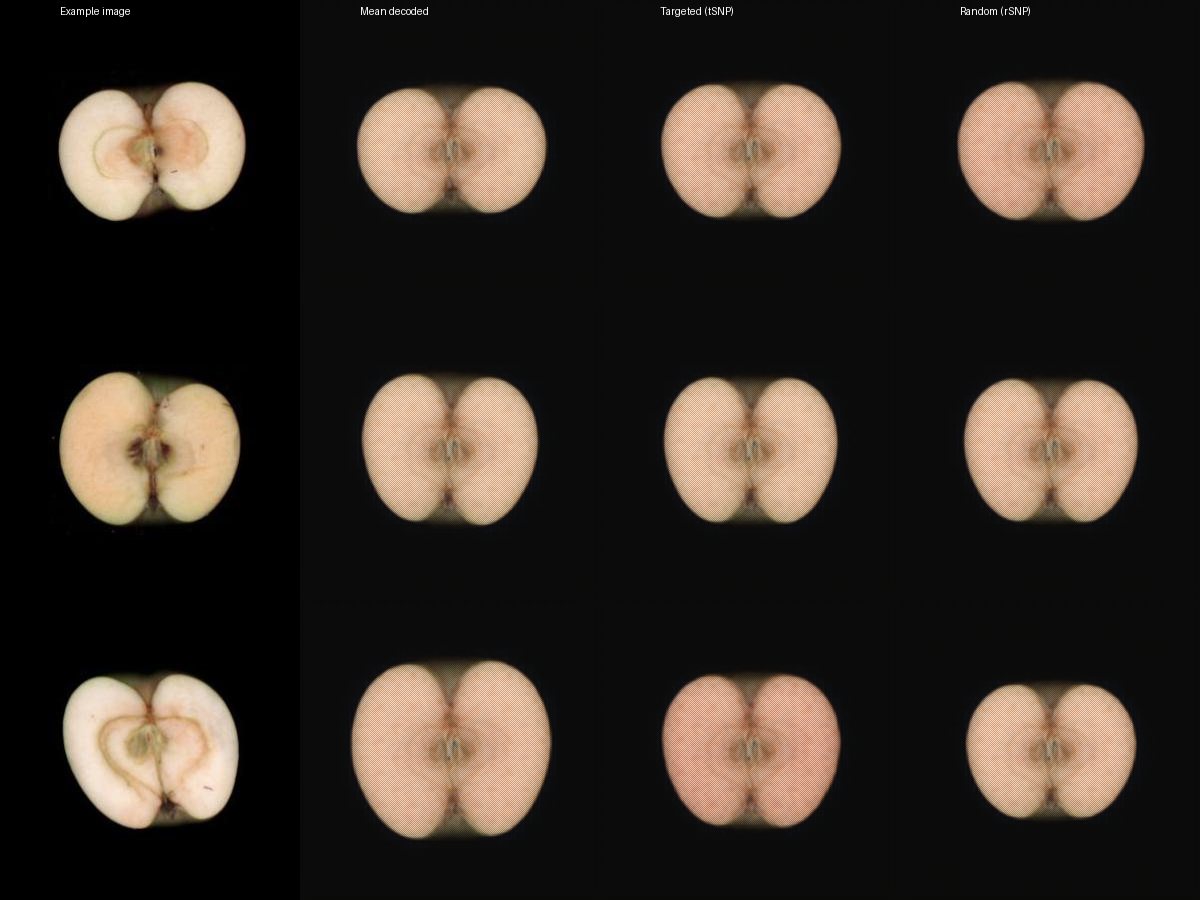

In [ ]:
from PIL import Image, ImageDraw
from torchvision.transforms.functional import to_pil_image

example_images = [Image.open(os.path.join(e, sorted(os.listdir(e))[0])) for e in folders]
ground_truth_images = [to_pil_image(e[0]) for e in test_random]

images_final = []
for i in range(3):
    images_final += [example_images[i], ground_truth_images[i], images_targeted[i], images_random[i]]

composition = Image.new("RGB", (images_final[0].width * 4, images_final[0].height * 3))
for i in range(3):
    for j in range(4):
        im = images_final[i * 4 + j]
        composition.paste(im, (im.width * j, im.height * i))
draw = ImageDraw.Draw(composition)
for j, label in enumerate(["Example image", "Mean decoded", "Targeted (tSNP)", "Random (rSNP)"]):
    draw.text((j * 300 + 60, 5), label, fill="white")
composition.save("/content/GenoDrawing_examples.png")
composition

## Interpretation and limitations

**What this run shows:** the released GenoDrawing stack (encoder/decoder + 150-SNP embedding
predictors) runs end-to-end on the authors' own 3-genotype example: SNP vectors produce
predicted 64-dim embeddings that decode into plausible apple-half images, and the targeted
(tSNP) and random (rSNP) versions differ visibly, mirroring the paper's Figure 1 and the
repository README example. The notebook-added embedding MAE column gives a run-level
plausibility check only.

**Limitations / スコープ外:**
- Single-run, 3-genotype example — **not** a verification of the paper's aggregate results
  (MAE 0.0864 vs 0.0944 over 320 genotypes × 100 models, FSI/SR metrics, Wasserstein tests,
  5-class shape accuracy). Those need the private apple image dataset (Dujak et al., on request).
- Training the autoencoder or predictors is out of scope.
- Known model limitations reported by the authors: mean-embedding decoding loses asymmetry
  (shoulder ratio), flesh color and lobule depth are not reproduced, and flat-globose
  apples dominate the training data (no oblong/oval classes are generated).

**結果の解釈（日本語）:** 公開済みモデルを著者の例 3 genotype で実行し，論文 Figure 1 相当の
4 列比較図を再構成しました．tSNP と rSNP で生成画像が異なる様子を確認できます．ただしこれは
1 例の実行であり，論文の集計結果（MAE・FSI/SR・Wasserstein・形状分類精度）の検証ではありません．

## Validation record & references

- Executed in a fresh Colab runtime via the project Colab CLI; see the run report for the
  recorded session, hardware, and timings. Delivered notebook: `p-b02aa84ae09932b7a23e3aff507295b7.ipynb`.
- Code: Fedjurrui/GenoDrawing @ f4704eabb7f084d990a6db27b108f17e621bcd8c (2023-11-15) —
  `GenoDrawing.ipynb`, `GenoDrawingLib/models.py`, `GenoDrawingLib/dataset.py` (verbatim, with the
  documented `import torchvision` addition). Note: the repository has no LICENSE file; code is
  used here as the paper's reference implementation with attribution.
- Weights: huggingface.co/aranzana-lab/genodrawing (MIT) — `encoder_7_2_2023_15h.h5`,
  `decoder_7_2_2023_15h.h5`; embedding predictors from the pinned repo (paths above).
- Paper: Dujak et al., Plant Phenomics 5:0113 (2023), doi:10.34133/plantphenomics.0113 (CC BY 4.0).
- PhenoPaper investigation `p-b02aa84ae09932b7a23e3aff507295b7-20260930T232523Z-3813401` was used
  as prior research guidance only; all cells here are sourced from the pinned code above.